real precision/recall vs is_synthetic_anomaly, all 4 methods

In [1]:
import pandas as pd; import numpy as np; import matplotlib.pyplot as plt; import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
from models import fit_kmeans, fit_dbscan, fit_gmm, fit_regression

In [2]:
df = pd.read_csv('repair_invoice_clean.csv')
y_true = df['is_synthetic_anomaly'].values

In [3]:
kres = fit_kmeans(df)
kflag = kres["flag"]

In [4]:
dres = fit_dbscan(df)
dflag = dres["flag"]

In [5]:
gres = fit_gmm(df)
gflag = gres["flag"]

In [6]:
flags = {"kmeans_flag": kflag, "dbscan_flag": dflag, "gmm_flag": gflag}
for name, f in flags.items():
    df[name] = f

In [7]:
rows = []
for name, f in flags.items():
    rows.append({"method": name, "flagged": int(f.sum()),
        "precision": precision_score(y_true, f, zero_division=0),
        "recall": recall_score(y_true, f, zero_division=0),
        "f1": f1_score(y_true, f, zero_division=0)})
metrics_df = pd.DataFrame(rows).set_index("method")
metrics_df

,flagged,precision,recall,f1
method,,,,
kmeans_flag,325,0.200000,0.216667,0.208000
dbscan_flag,852,0.214789,0.610000,0.317708
gmm_flag,323,0.173375,0.186667,0.179775


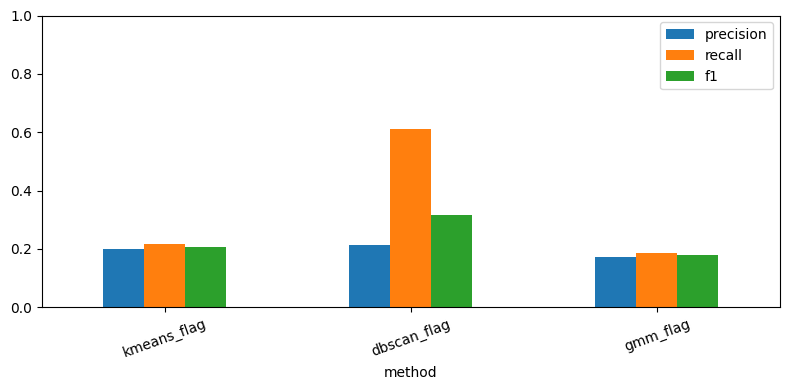

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
metrics_df[["precision", "recall", "f1"]].plot(kind="bar", ax=ax)
ax.set_ylim(0, 1); plt.xticks(rotation=20); plt.tight_layout(); plt.show()

In [9]:
at = df["anomaly_type"]
types = at.dropna().unique()
recall_by_type = pd.DataFrame(index=types, columns=flags.keys(), dtype=float)
for name, f in flags.items():
    for t in types:
        mask = (at == t).values
        recall_by_type.loc[t, name] = f[mask].mean()
recall_by_type["n"] = [at.value_counts()[t] for t in types]
recall_by_type

,kmeans_flag,dbscan_flag,gmm_flag,n
invoice_spike,0.101695,0.983051,0.457627,59
duration_mismatch,0.061224,1.000000,0.408163,49
combo,0.090909,0.257576,0.045455,66
estimate_inflate,0.877193,0.929825,0.105263,57
duplicate_billing,0.000000,0.086957,0.000000,69


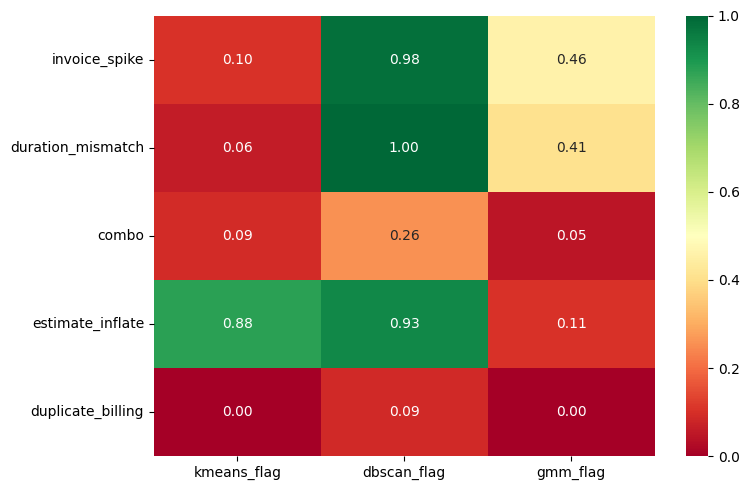

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(recall_by_type[list(flags.keys())].astype(float), annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1, ax=ax)
plt.tight_layout(); plt.show()